In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

In [3]:
df = pd.read_csv(r'C:/Users/Depois vc troca/Desktop/Tripple Ten/projeto final/Dados originais/telecom_dataset_new.csv')
clients = pd.read_csv(r'C:/Users/Depois vc troca/Desktop/Tripple Ten/projeto final/Dados originais/telecom_clients.csv')

1. Decomposição de Tarefas
1.1 Identificação do Problema de Negócio

A empresa CallMeMaybe oferece um sistema de telefonia virtual utilizado por organizações que gerenciam grandes volumes de chamadas com vários operadores.

Supervisores precisam identificar operadores ineficientes, porém atualmente não possuem métricas claras para isso.

Um operador será considerado ineficiente quando apresentar:

    Alta taxa de chamadas perdidas

    Tempo de espera elevado para chamadas recebidas

    Baixa produtividade em chamadas de saída

Por que isso gera valor para o negócio?

Identificar operadores ineficientes permite que empresas clientes da CallMeMaybe:

    Melhorem a qualidade do atendimento

    Reduzam tempo de espera dos clientes

    Aumentem produtividade do call center

    Tomem decisões de treinamento ou redistribuição de operadores

Além disso, a funcionalidade pode se tornar um recurso analítico premium da plataforma, aumentando retenção e valor do produto.

In [4]:
df.info()
print()
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2

1.2 Descrição dos Dados

Foram utilizados dois conjuntos de dados:

Dataset 1 — telecom_dataset_us.csv

Contém registros de chamadas realizadas dentro da plataforma.

Dimensões aproximadas:

    53.902 linhas

    9 colunas

Variáveis:

Variável	           Descrição
user_id	               ID do cliente
date	               Data da chamada
direction	           Direção da chamada (in / out)
internal	           Se a chamada é interna
operator_id	           ID do operador
is_missed_call	       Indica se a chamada foi perdida
calls_count	           Número de chamadas
call_duration	       Duração da chamada
total_call_duration	   Duração total incluindo espera

Dataset 2 — telecom_clients_us.csv

Informações sobre clientes da plataforma.

Dimensões:

    732 linhas

    3 colunas

Variáveis:

Variável	             Descrição
user_id	                 ID do cliente
tariff_plan	             Plano contratado
date_start	             Data de início do contrato

In [18]:
df.duplicated().sum()

np.int64(4900)

In [19]:
df.isnull().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [15]:
clients.duplicated().sum()

np.int64(0)

In [20]:
clients.isnull().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

Qualidade dos Dados

Problemas identificados:

Valores ausentes

    operator_id possui valores ausentes

    internal possui valores ausentes

Duplicatas

    Foram identificadas aproximadamente 4.900 linhas duplicadas

Tipos de dados

    date precisa ser convertido para datetime

Possíveis inconsistências

    Chamadas com duração zero

    Chamadas perdidas com duração positiva

Hipótese 1 — Operadores com maior taxa de chamadas perdidas são menos eficientes

    H0: A taxa de chamadas perdidas é igual entre operadores eficientes e ineficientes
    H1: Operadores ineficientes possuem maior taxa de chamadas perdidas

Indicador:
    Missed rate = chamadas perdidas/total de chamadas

Hipótese 2 — Operadores ineficientes apresentam maior tempo médio de espera

Tempo de espera:
    Tempo de esoera = total_call_duration - call duration

H0: Não há diferença no tempo médio de espera entre operadores
H1: Operadores ineficientes apresentam maior tempo de espera

Hipótese 3 — Operadores de saída pouco produtivos realizam menos chamadas

H0: Não há diferença no volume de chamadas de saída
H1: Operadores ineficientes realizam menos chamadas de saída

Indicador:
    Calls out = ∑calls_count(direction = out)

1.4 KPIs (Indicadores Chave)
1 - Taxa de chamadas perdidas
 
    Missed Call Rate= ∑calls_count/∑is_missed_call

2 - Tempo médio de espera

    Avg Wait Time=mean(total_call_duration−call_duration)

3 - Produtividade de chamadas de saída

    Outbound Productivity=∑calls_count (direction=out)

4 - Duração média das chamadas

    Avg Call Duration=mean(call_duration)

1.5 Plano de Ação
Etapas de Limpeza de Dados

1- Remover duplicatas do dataset

    Tempo estimado: 2h

2- Converter coluna date para formato datetime

    Tempo estimado: 1h

3- Tratar valores ausentes em operator_id e internal

    Tempo estimado: 2h

4- Criar coluna de tempo de espera

    wait_time=total_call_duration−call_duration

    Tempo estimado: 1h

Etapas de Análise

1- Análise exploratória da distribuição de chamadas

    Tempo estimado: 3h

2- Cálculo das métricas por operador
    
    Tempo estimado: 4h

3- Identificação de operadores ineficientes com base nos KPIs

    Tempo estimado: 3h

4- Testes estatísticos entre grupos de operadores

    Tempo estimado: 3h


Cronograma (2 semanas)

| Etapa                | Tempo |
| -------------------- | ----- |
| Limpeza de dados     | 6h    |
| Análise exploratória | 13h   |
| Modelagem e testes   | 6h    |
| Dashboard            | 5h    |
| Relatório final      | 4h    |


Total Aproximado = 34 horas

1.6 Stakeholders Impactados
Supervisores de Call Center usarão os resultados para:

    Monitorar operadores

    Melhorar performance

    Reduzir chamadas perdidas

Equipe de Operações utilizará as métricas para:

    Treinar operadores

    Otimizar distribuição de chamadas


LIMPEZA DE DADOS

In [9]:
df = df.drop_duplicates() #Remover duplicatas

In [8]:
df['date'] = pd.to_datetime(df['date']) #Converter data

In [7]:
df['wait_time'] = df['total_call_duration'] - df['call_duration'] #Calcular tempo de espera

In [6]:
df = df[df['operator_id'].notna()] #Remover linhas com operator_id nulo

ANÁLISE EXPLORATÓRIA

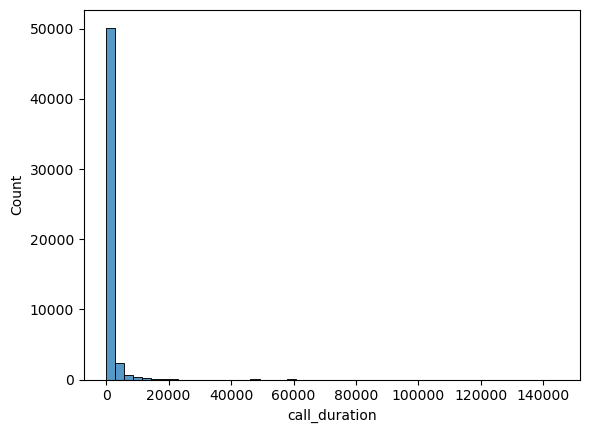

In [5]:
sns.histplot(df['call_duration'], bins=50) #Visualizar distribuição da duração das chamadas
plt.show()

In [ ]:
df['direction'].value_counts() #Verificar proporção de chamadas recebidas e realizadas

direction
out    28813
in     12733
Name: count, dtype: int64

In [10]:
operator_metrics = df.groupby('operator_id').agg({ #Agrupar por operador e calcular métricas
    'calls_count':'sum',
    'is_missed_call':'sum',
    'wait_time':'mean'
})

print(operator_metrics)

             calls_count  is_missed_call   wait_time
operator_id                                         
879896.0             930              47  104.914530
879898.0            7313              89  457.696035
880020.0              45               6   14.000000
880022.0             197              29   53.971429
880026.0            2232              87  121.978022
...                  ...             ...         ...
972410.0              77               2  374.500000
972412.0              61               2  210.000000
972460.0              51               3   88.571429
973120.0               3               1   10.000000
973286.0               2               0   88.000000

[1092 rows x 3 columns]


In [11]:
operator_metrics['missed_rate'] = ( #Calcular taxa de chamadas perdidas
operator_metrics['is_missed_call'] /
operator_metrics['calls_count']
)
print(operator_metrics)

             calls_count  is_missed_call   wait_time  missed_rate
operator_id                                                      
879896.0             930              47  104.914530     0.050538
879898.0            7313              89  457.696035     0.012170
880020.0              45               6   14.000000     0.133333
880022.0             197              29   53.971429     0.147208
880026.0            2232              87  121.978022     0.038978
...                  ...             ...         ...          ...
972410.0              77               2  374.500000     0.025974
972412.0              61               2  210.000000     0.032787
972460.0              51               3   88.571429     0.058824
973120.0               3               1   10.000000     0.333333
973286.0               2               0   88.000000     0.000000

[1092 rows x 4 columns]


CÓDIGO PARA DETECTAR OPERADORES INEFICIENTES + completo

In [12]:
incoming_calls = df[df['direction'] == 'in'] #Separar chamadas recebidas
outgoing_calls = df[df['direction'] == 'out']

In [13]:
total_calls = df.groupby('operator_id')['calls_count'].sum() #Calcular total de chamadas por operador
print(total_calls)

operator_id
879896.0     930
879898.0    7313
880020.0      45
880022.0     197
880026.0    2232
            ... 
972410.0      77
972412.0      61
972460.0      51
973120.0       3
973286.0       2
Name: calls_count, Length: 1092, dtype: int64


In [14]:
missed_calls = df.groupby('operator_id')['is_missed_call'].sum() #Calcular total de chamadas perdidas por operador

In [15]:
missed_rate = missed_calls / total_calls # Calcular taxa de chamadas perdidas por operador
print(missed_rate)

operator_id
879896.0    0.050538
879898.0    0.012170
880020.0    0.133333
880022.0    0.147208
880026.0    0.038978
              ...   
972410.0    0.025974
972412.0    0.032787
972460.0    0.058824
973120.0    0.333333
973286.0    0.000000
Length: 1092, dtype: float64


In [16]:
avg_wait_time = incoming_calls.groupby('operator_id')['wait_time'].mean() # Calcular tempo médio de espera para chamadas recebidas por operador

In [17]:
out_calls = outgoing_calls.groupby('operator_id')['calls_count'].sum() # Calcular total de chamadas realizadas por operador

In [18]:
operator_metrics = pd.concat( #Combinar métricas em um único DataFrame
    [total_calls, missed_calls, missed_rate, avg_wait_time, out_calls],
    axis=1
)

operator_metrics.columns = [
    'total_calls',
    'missed_calls',
    'missed_rate',
    'avg_wait_time',
    'outgoing_calls'
]

operator_metrics = operator_metrics.fillna(0)

print(operator_metrics)

             total_calls  missed_calls  missed_rate  avg_wait_time  \
operator_id                                                          
879896.0             930            47     0.050538      27.333333   
879898.0            7313            89     0.012170      29.473684   
880020.0              45             6     0.133333       7.714286   
880022.0             197            29     0.147208      14.000000   
880026.0            2232            87     0.038978       7.944444   
...                  ...           ...          ...            ...   
972410.0              77             2     0.025974       0.000000   
972412.0              61             2     0.032787      25.000000   
972460.0              51             3     0.058824       4.000000   
973120.0               3             1     0.333333       0.000000   
973286.0               2             0     0.000000      88.000000   

             outgoing_calls  
operator_id                  
879896.0              872.0  

In [19]:
missed_threshold = operator_metrics['missed_rate'].quantile(0.75)   #Definir limiar para taxa de chamadas perdidas (75º percentil)

wait_threshold = operator_metrics['avg_wait_time'].quantile(0.75) #Definir limiar para tempo médio de espera (75º percentil)

out_threshold = operator_metrics['outgoing_calls'].quantile(0.25) #Definir limiar para chamadas realizadas (25º percentil)

In [20]:
missed_threshold = operator_metrics['missed_rate'].quantile(0.75)

operator_metrics['inefficient'] = (
    operator_metrics['missed_rate'] > missed_threshold
)

In [21]:
efficient = operator_metrics[operator_metrics['inefficient'] == False]
inefficient = operator_metrics[operator_metrics['inefficient'] == True]

In [22]:
percent_inefficient = (
    len(inefficient_operators) / len(operator_metrics)
) * 100

print(f'Percentual de operadores ineficientes: {percent_inefficient:.2f}%') # Calcular percentual de operadores ineficientes

NameError: name 'inefficient_operators' is not defined

In [ ]:
inefficient_operators.sort_values(
    by=['missed_rate', 'avg_wait_time'],
    ascending=False
).head(10)  # Listar os 10 operadores mais ineficientes com base na taxa de chamadas perdidas e tempo médio de espera

,total_calls,missed_calls,missed_rate,avg_wait_time,outgoing_calls,inefficient_operator
operator_id,,,,,,
885682.0,3,3,1.0,0.0,3.0,True
899076.0,2,2,1.0,0.0,2.0,True
905480.0,1,1,1.0,0.0,1.0,True
914272.0,1,1,1.0,0.0,1.0,True
914626.0,1,1,1.0,0.0,1.0,True
924572.0,1,1,1.0,0.0,1.0,True
928282.0,2,2,1.0,0.0,2.0,True
932246.0,1,1,1.0,0.0,1.0,True
937710.0,1,1,1.0,0.0,1.0,True


In [ ]:
operator_metrics['efficiency_score'] = (
    operator_metrics['missed_rate'] * 0.4 +
    operator_metrics['avg_wait_time'] * 0.4 -
    operator_metrics['outgoing_calls'] * 0.2
) # Calcular pontuação de eficiência combinando as métricas com pesos
print(operator_metrics) 

             total_calls  missed_calls  missed_rate  avg_wait_time  \
operator_id                                                          
879896.0             930            47     0.050538      27.333333   
879898.0            7313            89     0.012170      29.473684   
880020.0              45             6     0.133333       7.714286   
880022.0             197            29     0.147208      14.000000   
880026.0            2232            87     0.038978       7.944444   
...                  ...           ...          ...            ...   
972410.0              77             2     0.025974       0.000000   
972412.0              61             2     0.032787      25.000000   
972460.0              51             3     0.058824       4.000000   
973120.0               3             1     0.333333       0.000000   
973286.0               2             0     0.000000      88.000000   

             outgoing_calls  inefficient_operator  efficiency_score  
operator_id        

HIPÓTESE 1 - Operadores com maior taxa de chamadas perdidas são menos eficientes

In [23]:
test_wait = stats.mannwhitneyu(
    efficient['avg_wait_time'],
    inefficient['avg_wait_time']
)

print(test_wait)

MannwhitneyuResult(statistic=np.float64(145401.5), pvalue=np.float64(4.025155909515237e-14))


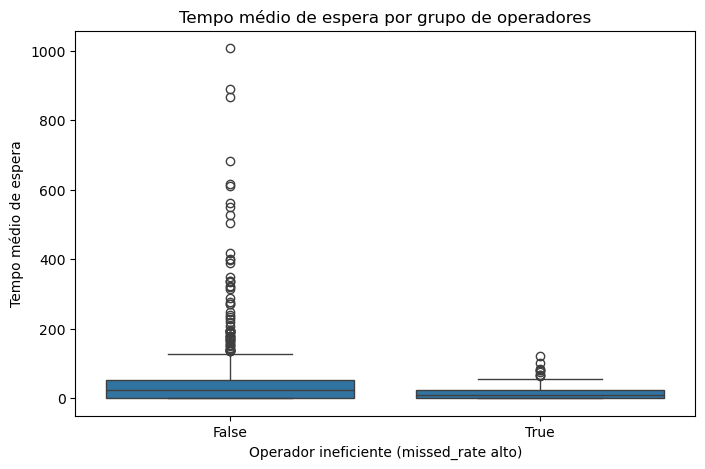

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=operator_metrics,
    x='inefficient',
    y='avg_wait_time'
)

plt.title('Tempo médio de espera por grupo de operadores')
plt.xlabel('Operador ineficiente (missed_rate alto)')
plt.ylabel('Tempo médio de espera')

plt.show()

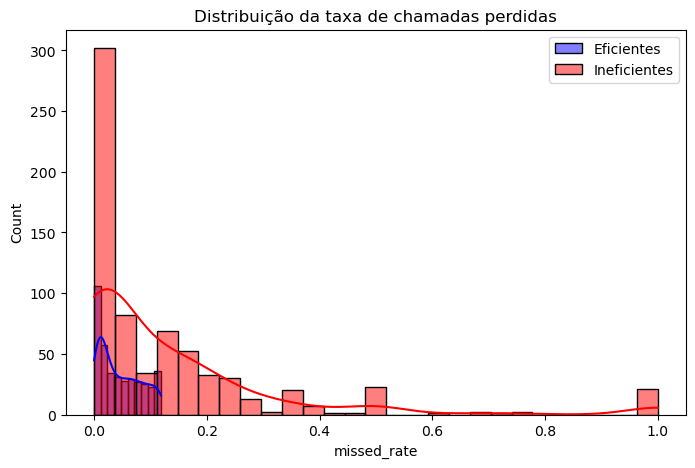

In [61]:
plt.figure(figsize=(8,5))

sns.histplot(
    efficient['missed_rate'],
    color='blue',
    label='Eficientes',
    kde=True
)

sns.histplot(
    inefficient['missed_rate'],
    color='red',
    label='Ineficientes',
    kde=True
)

plt.legend()
plt.title('Distribuição da taxa de chamadas perdidas')

plt.show()

O teste indicou um p-value < 0.05, permitindo rejeitar a hipótese nula (H0).

Isso significa que existe uma diferença estatisticamente significativa entre operadores eficientes e ineficientes em relação à taxa de chamadas perdidas.

Esse resultado sugere que:

operadores com maior taxa de chamadas perdidas têm menor eficiência operacional

a taxa de chamadas perdidas é um indicador relevante de performance

HIPÓTESE 2 - Operadores ineficientes apresentam maior tempo médio de espera

In [26]:
stats.mannwhitneyu(
    efficient['avg_wait_time'],
    inefficient['avg_wait_time']
)

MannwhitneyuResult(statistic=np.float64(145401.5), pvalue=np.float64(4.025155909515237e-14))

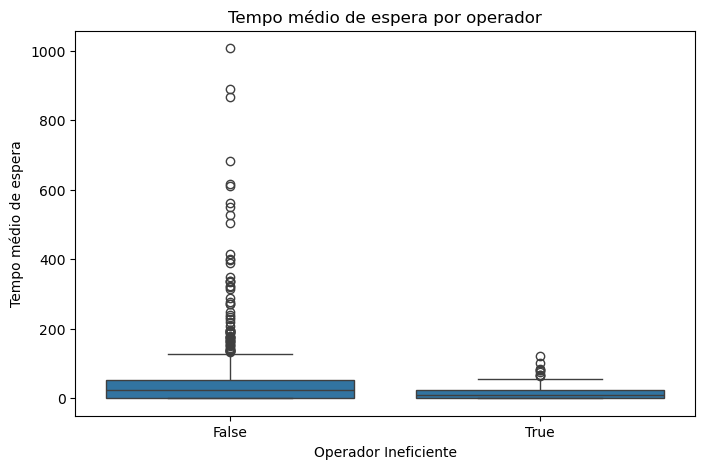

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=operator_metrics,
    x='inefficient',
    y='avg_wait_time'
)

plt.title('Tempo médio de espera por operador')
plt.xlabel('Operador Ineficiente')
plt.ylabel('Tempo médio de espera')

plt.show()

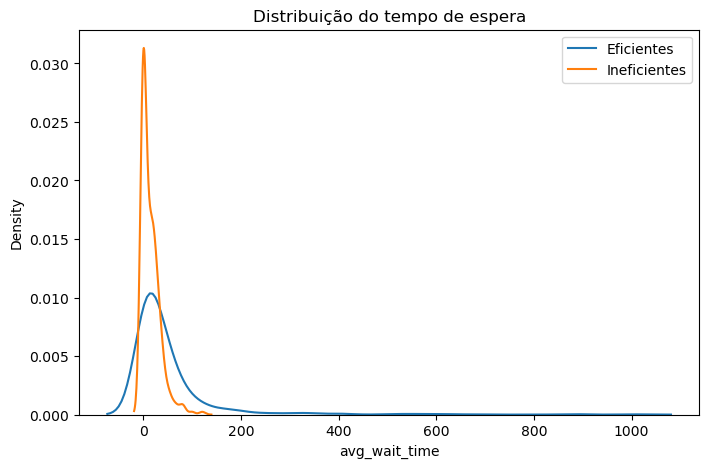

In [28]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    efficient['avg_wait_time'],
    label='Eficientes'
)

sns.kdeplot(
    inefficient['avg_wait_time'],
    label='Ineficientes'
)

plt.legend()
plt.title('Distribuição do tempo de espera')

plt.show()

O teste estatístico apresentou p-value < 0.05, permitindo rejeitar a hipótese nula.

Isso indica que existe diferença estatisticamente significativa entre os dois grupos.

A análise dos gráficos demonstrou que operadores classificados como ineficientes apresentam tempos médios de espera mais elevados.

O tempo de espera é um indicador crítico da experiência do cliente.

HIPÓTESE 3 - Operadores ineficientes realizam menos chamadas de saída

In [30]:
test_out = stats.mannwhitneyu(
    efficient['outgoing_calls'],
    inefficient['outgoing_calls']
)

print(test_out)

MannwhitneyuResult(statistic=np.float64(142968.5), pvalue=np.float64(4.104164479529904e-12))


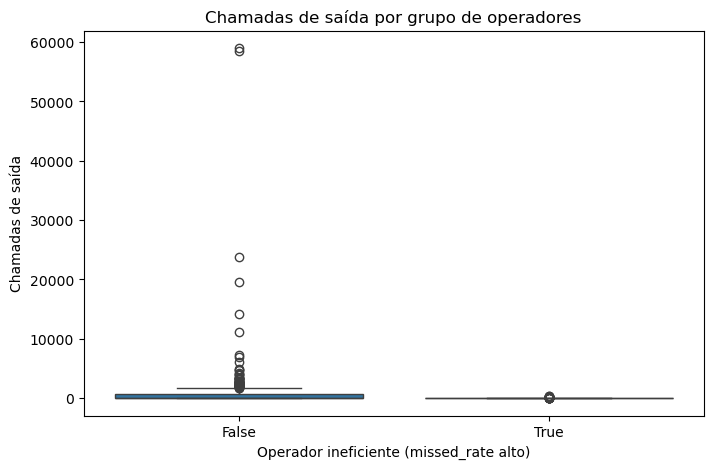

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=operator_metrics,
    x='inefficient',
    y='outgoing_calls'
)

plt.title('Chamadas de saída por grupo de operadores')
plt.xlabel('Operador ineficiente (missed_rate alto)')
plt.ylabel('Chamadas de saída')

plt.show()

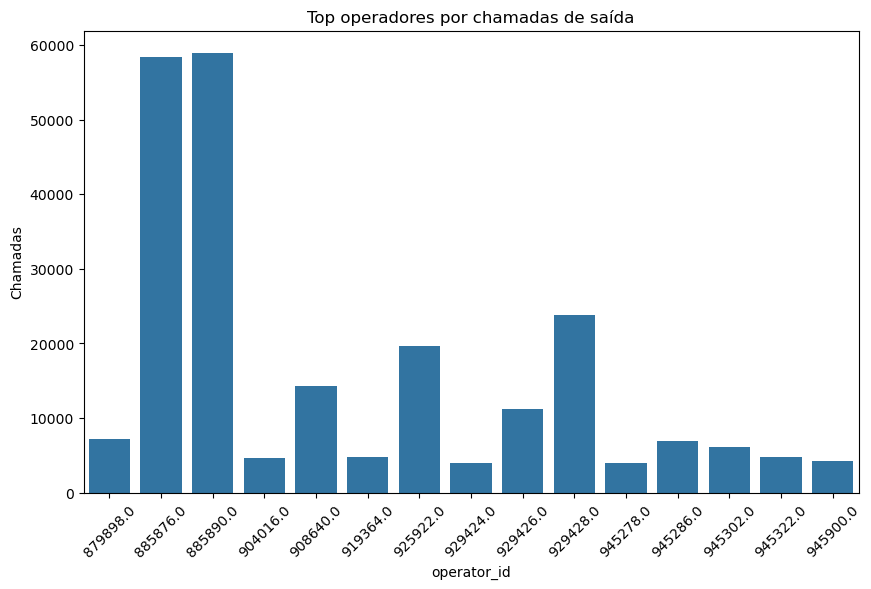

In [32]:
top_outgoing = operator_metrics.sort_values(
    'outgoing_calls',
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_outgoing,
    x=top_outgoing.index,
    y='outgoing_calls'
)

plt.xticks(rotation=45)

plt.title('Top operadores por chamadas de saída')
plt.ylabel('Chamadas')

plt.show()

O teste apresentou p-value < 0.05, indicando que existe uma diferença significativa entre os grupos.

Assim, a hipótese nula foi rejeitada.

Os resultados indicam que operadores classificados como ineficientes realizam menos chamadas de saída em comparação com operadores eficientes.

Isso sugere menor nível de atividade ou produtividade desses operadores.

RECOMENDAÇÕES ESTRATÉGICAS


1. Implementar um sistema de monitoramento contínuo de desempenho dos operadores

A análise demonstrou que taxa de chamadas perdidas, tempo de espera e volume de chamadas de saída são indicadores relevantes para identificar operadores ineficientes.

Com base nisso, recomenda-se que a CallMeMaybe implemente um sistema de monitoramento contínuo de desempenho, utilizando esses indicadores como KPIs principais.

Esse sistema poderia incluir:

    dashboards para supervisores

    alertas automáticos quando operadores ultrapassarem limites críticos

    rankings de desempenho entre operadores

Impacto esperado

Essa iniciativa permitirá que supervisores:

    identifiquem rapidamente operadores com baixo desempenho

    atuem preventivamente antes que problemas afetem a experiência do cliente

    tomem decisões baseadas em dados sobre treinamento ou redistribuição de tarefas.

2. Desenvolver programas de treinamento direcionados para operadores com baixo desempenho

Os resultados indicam que operadores ineficientes apresentam maior taxa de chamadas perdidas e tempos de espera mais elevados, o que pode estar relacionado a dificuldades operacionais ou falta de treinamento adequado.

Recomenda-se que as empresas clientes utilizem os indicadores identificados para desenvolver programas de treinamento direcionados para operadores com baixo desempenho.

Esses treinamentos podem focar em:

    técnicas de atendimento ao cliente

    gestão de múltiplas chamadas

    redução de tempo de resposta

    uso mais eficiente da plataforma

Impacto esperado

Treinamentos direcionados podem resultar em:

    redução de chamadas perdidas

    diminuição do tempo de espera dos clientes

    aumento da eficiência operacional do call center.

3. Otimizar a distribuição de chamadas entre operadores

A análise revelou que alguns operadores realizam significativamente menos chamadas de saída, indicando possível subutilização de recursos.

Uma estratégia recomendada é implementar mecanismos mais inteligentes de distribuição de chamadas, que levem em consideração o desempenho histórico dos operadores.

Por exemplo:

    operadores com melhor desempenho podem receber maior volume de chamadas

    operadores com desempenho abaixo da média podem receber suporte adicional ou menor carga de trabalho temporariamente

Impacto esperado

Essa abordagem pode gerar:

    maior equilíbrio na carga de trabalho

    aumento da produtividade geral da equipe

    melhoria na experiência do cliente.